In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("healthcare_cleaned.csv.xls", sep="\t")

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Stay_Duration_Days,Daily_Billing_Amount
0,Aaron Adams,38,Female,O-,Cancer,10/03/2021,Norma Li,Hart LLC,UnitedHealthcare,26052.11,363,Elective,29/03/2021,Lipitor,Inconclusive,19,1371.16
1,Aaron Aguirre,36,Male,A-,Diabetes,26/02/2023,Katrina Luna,Murray-Shelton,UnitedHealthcare,27087.56,300,Emergency,13/03/2023,Aspirin,Inconclusive,15,1805.84
2,Aaron Anderson,50,Female,A+,Asthma,18/12/2020,Kenneth Jennings,Tanner-Cox,Cigna,39804.66,196,Urgent,15/01/2021,Aspirin,Inconclusive,28,1421.60
3,Aaron Anderson md,20,Female,A-,Hypertension,28/03/2021,Tammy Perez,Ritter LLC,UnitedHealthcare,16846.42,249,Elective,9/04/2021,Paracetamol,Abnormal,12,1403.87
4,Aaron Archer,49,Female,B-,Cancer,10/01/2021,Cynthia Villanueva,"Montes Case and Mendez,",Medicare,10602.08,108,Urgent,17/01/2021,Paracetamol,Inconclusive,7,1514.58


In [ ]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"], format="mixed")
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], format="mixed")

print(df[["Date of Admission", "Discharge Date"]].head())

  Date of Admission Discharge Date
0        2021-10-03     2021-03-29
1        2023-02-26     2023-03-13
2        2020-12-18     2021-01-15
3        2021-03-28     2021-09-04
4        2021-10-01     2021-01-17


In [ ]:
total_records = len(df)
unique_names = df["Name"].nunique()
total_billing = df["Billing Amount"].sum()
average_billing = df["Billing Amount"].mean()
median_billing = df["Billing Amount"].median()
average_age = df["Age"].mean()
average_stay = df["Stay_Duration_Days"].mean()
median_stay = df["Stay_Duration_Days"].median()

print("Total Records:", total_records)
print("Unique Names:", unique_names)
print("Total Billing:", round(total_billing, 2))
print("Average Billing:", round(average_billing, 2))
print("Median Billing:", round(median_billing, 2))
print("Average Age:", round(average_age, 2))
print("Average Stay:", round(average_stay, 2))
print("Median Stay:", round(median_stay, 2))

Total Records: 49996
Unique Names: 40235
Total Billing: 1277748058.11
Average Billing: 25557.01
Median Billing: 25541.31
Average Age: 51.56
Average Stay: 15.5
Median Stay: 15.0


Gender
Female    25009
Male      24987
Name: count, dtype: int64


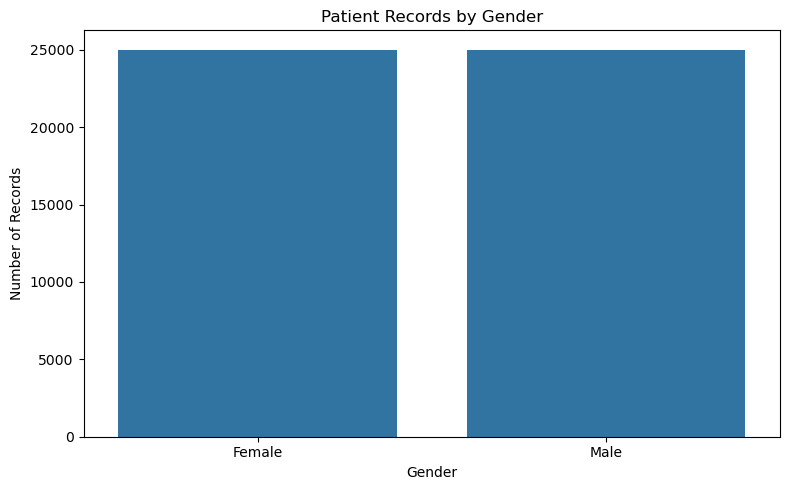

In [ ]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Gender")

plt.title("Patient Records by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

count    49996.000000
mean        51.564185
std         19.591954
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64


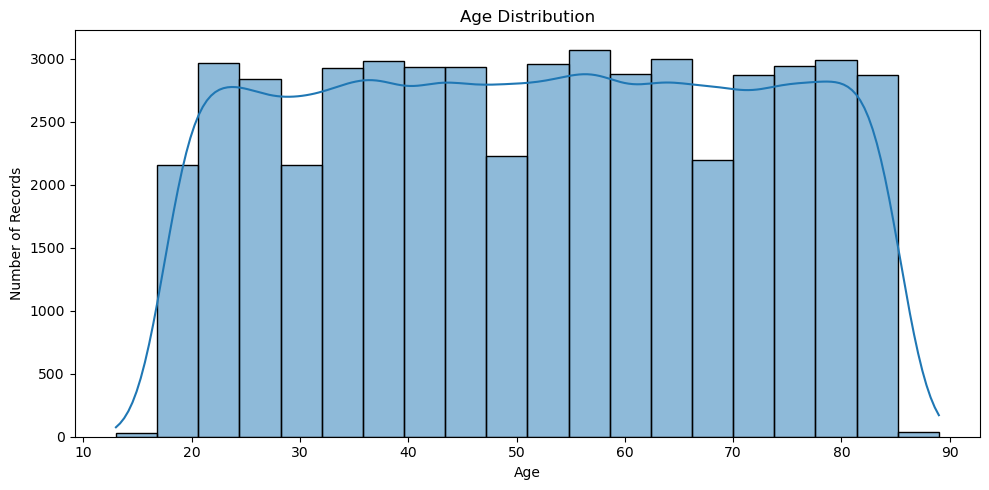

In [ ]:
print(df["Age"].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

Age Group
0-18        755
19-30      8691
31-45     11020
46-60     11173
61-75     10989
76-100     7368
Name: count, dtype: int64


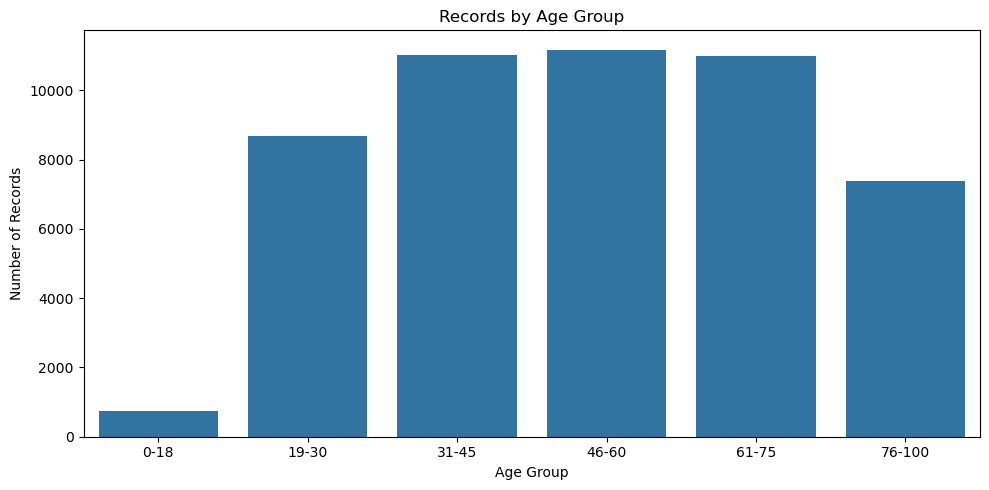

In [ ]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 75, 100],
    labels=["0-18", "19-30", "31-45", "46-60", "61-75", "76-100"]
)

age_group_counts = df["Age Group"].value_counts().sort_index()

print(age_group_counts)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Age Group")

plt.title("Records by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

Medical Condition
Arthritis       8438
Diabetes        8383
Hypertension    8318
Cancer          8293
Obesity         8292
Asthma          8272
Name: count, dtype: int64


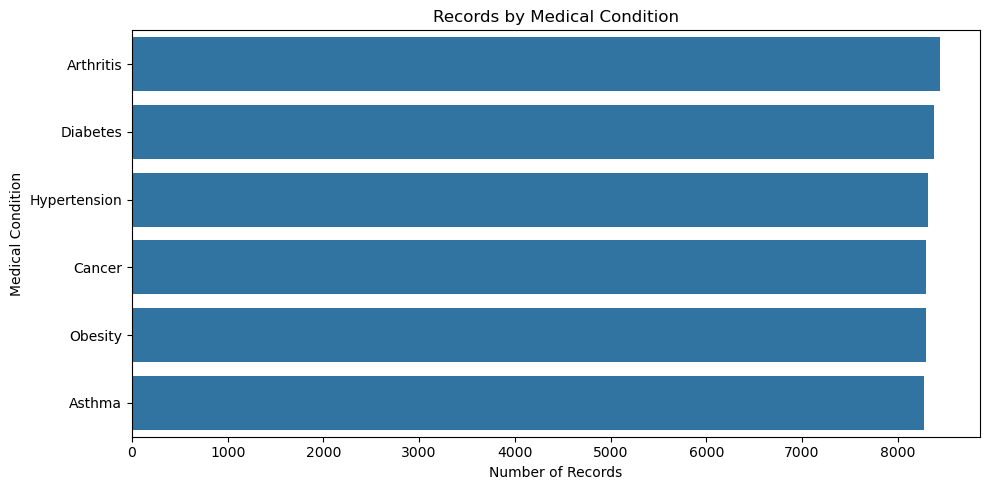

In [ ]:
condition_counts = df["Medical Condition"].value_counts()

print(condition_counts)

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y="Medical Condition",
    order=condition_counts.index
)

plt.title("Records by Medical Condition")
plt.xlabel("Number of Records")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.show()

In [ ]:
billing_by_condition = (
    df.groupby("Medical Condition")["Billing Amount"]
    .agg(["count", "sum", "mean", "median"])
    .sort_values("mean", ascending=False)
)

billing_by_condition

,count,sum,mean,median
Medical Condition,,,,
Obesity,8292,2.138186e+08,25786.131393,26134.725
Asthma,8272,2.124548e+08,25683.606587,25678.670
Diabetes,8383,2.150562e+08,25653.842634,25619.170
Hypertension,8318,2.120571e+08,25493.762037,25264.310
Arthritis,8438,2.150634e+08,25487.482119,25555.365
Cancer,8293,2.092980e+08,25237.913104,25060.650


Admission Type
Elective     16826
Urgent       16783
Emergency    16387
Name: count, dtype: int64


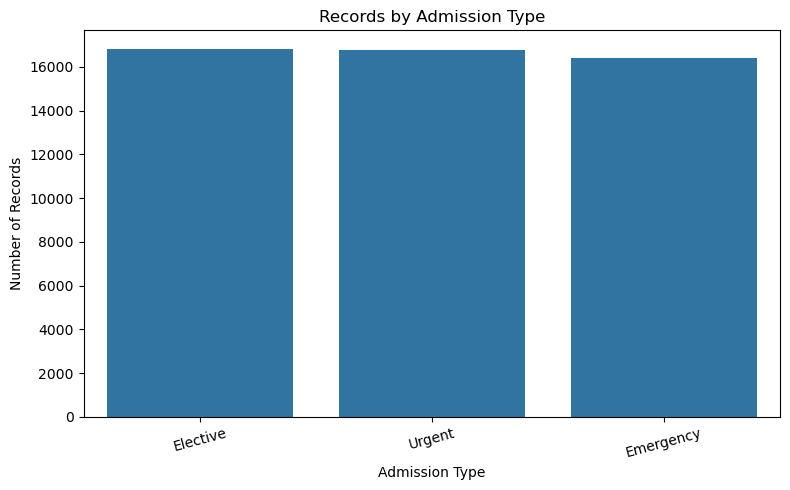

In [ ]:
admission_counts = df["Admission Type"].value_counts()

print(admission_counts)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Admission Type",
    order=admission_counts.index
)

plt.title("Records by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
billing_by_admission = (
    df.groupby("Admission Type")["Billing Amount"]
    .agg(["count", "sum", "mean", "median"])
    .sort_values("mean", ascending=False)
)

billing_by_admission


,count,sum,mean,median
Admission Type,,,,
Elective,16826,4.311067e+08,25621.458785,25653.88
Emergency,16387,4.183363e+08,25528.547914,25487.49
Urgent,16783,4.283051e+08,25520.173862,25530.04


In [ ]:
admission_condition = pd.crosstab(
    df["Medical Condition"],
    df["Admission Type"]
)

admission_condition

Admission Type,Elective,Emergency,Urgent
Medical Condition,,,
Arthritis,2823,2786,2829
Asthma,2809,2690,2773
Cancer,2818,2708,2767
Diabetes,2769,2712,2902
Hypertension,2884,2680,2754
Obesity,2723,2811,2758


In [ ]:
hospital_billing = (
    df.groupby("Hospital")["Billing Amount"]
    .agg(["count", "sum", "mean", "median"])
    .sort_values("sum", ascending=False)
)

hospital_billing.head(15)

,count,sum,mean,median
Hospital,,,,
Johnson PLC,35,1040431.60,29726.617143,30447.000
LLC Smith,40,948561.10,23714.027500,19516.355
Ltd Smith,35,915166.77,26147.622000,25306.050
Smith PLC,33,901359.29,27313.917879,28675.530
Smith Ltd,35,897694.86,25648.424571,23435.930
Group Smith,30,847450.76,28248.358667,25115.165
Johnson Inc,29,809053.87,27898.409310,31095.430
Inc Brown,25,801547.73,32061.909200,35319.120
LLC Johnson,28,766627.99,27379.571071,24754.835


Insurance Provider
Cigna               10090
Medicare            10057
UnitedHealthcare    10001
Blue Cross          10001
Aetna                9847
Name: count, dtype: int64


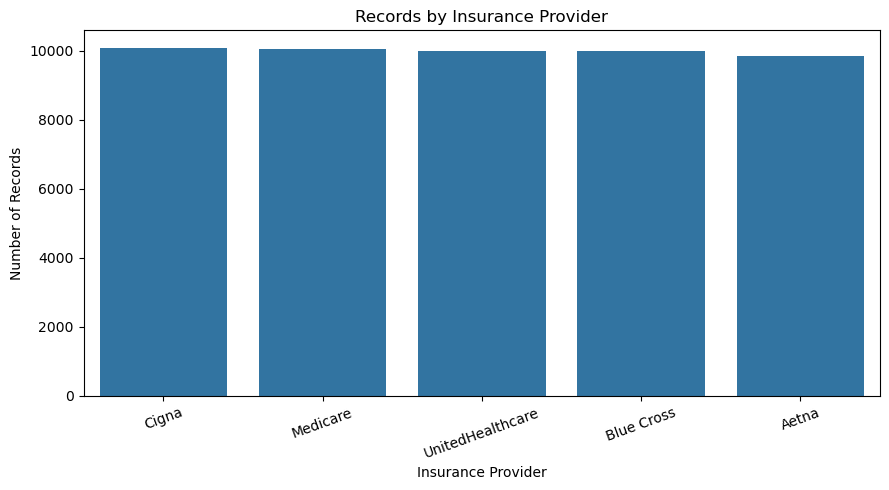

In [ ]:
insurance_counts = df["Insurance Provider"].value_counts()

print(insurance_counts)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Insurance Provider",
    order=insurance_counts.index
)

plt.title("Records by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
insurance_billing = (
    df.groupby("Insurance Provider")["Billing Amount"]
    .agg(["count", "sum", "mean", "median"])
    .sort_values("mean", ascending=False)
)

insurance_billing

,count,sum,mean,median
Insurance Provider,,,,
Blue Cross,10001,2.565489e+08,25652.320601,25644.980
Medicare,10057,2.577197e+08,25625.901882,25616.660
Aetna,9847,2.516957e+08,25560.644445,25747.810
Cigna,10090,2.576357e+08,25533.770469,25543.825
UnitedHealthcare,10001,2.541481e+08,25412.268240,25208.460


count    49996.000000
mean        15.500960
std          8.651397
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Stay_Duration_Days, dtype: float64


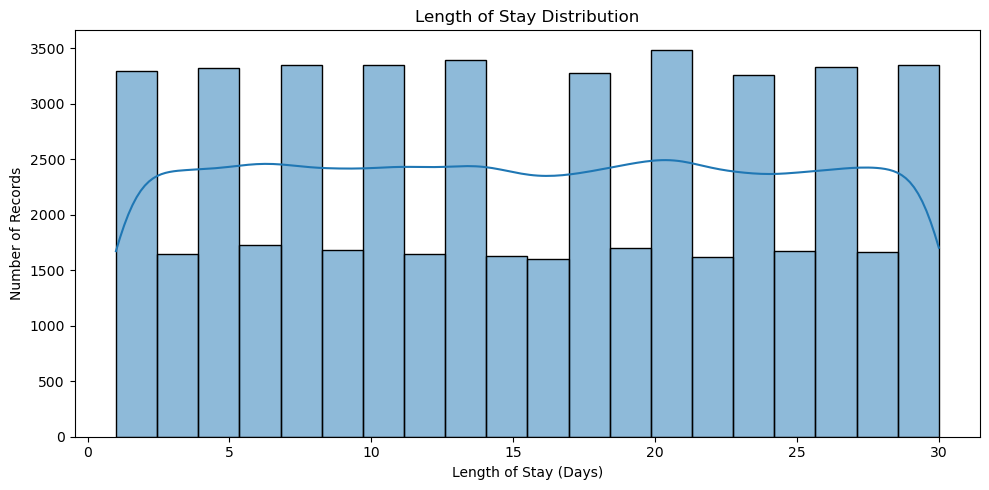

In [ ]:
print(df["Stay_Duration_Days"].describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Stay_Duration_Days"],
    bins=20,
    kde=True
)

plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [ ]:
stay_by_condition = (
    df.groupby("Medical Condition")["Stay_Duration_Days"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

stay_by_condition

,count,mean,median
Medical Condition,,,
Asthma,8272,15.665135,16.0
Arthritis,8438,15.555582,16.0
Cancer,8293,15.473170,15.0
Obesity,8292,15.456223,15.0
Hypertension,8318,15.446862,15.0
Diabetes,8383,15.409400,15.0


In [ ]:
stay_by_admission = (
    df.groupby("Admission Type")["Stay_Duration_Days"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

stay_by_admission

,count,mean,median
Admission Type,,,
Emergency,16387,15.595838,16.0
Elective,16826,15.517057,15.0
Urgent,16783,15.392183,15.0


In [ ]:
correlation = df["Stay_Duration_Days"].corr(
    df["Billing Amount"]
)

print("Correlation between Length of Stay and Billing:", round(correlation, 3))

Correlation between Length of Stay and Billing: -0.005


In [ ]:
test_condition = pd.crosstab(
    df["Medical Condition"],
    df["Test Results"]
)

test_condition

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,2908,2789,2741
Asthma,2697,2721,2854
Cancer,2797,2750,2746
Diabetes,2831,2765,2787
Hypertension,2721,2788,2809
Obesity,2818,2728,2746


In [ ]:
# Test Results Percentage by Medical Condition

test_result_pct = pd.crosstab(
    df["Medical Condition"],
    df["Test Results"],
    normalize="index"
) * 100

# Round percentages
test_result_pct = test_result_pct.round(2)

print(test_result_pct)

Test Results       Abnormal  Inconclusive  Normal
Medical Condition                                
Arthritis             34.46         33.05   32.48
Asthma                32.60         32.89   34.50
Cancer                33.73         33.16   33.11
Diabetes              33.77         32.98   33.25
Hypertension          32.71         33.52   33.77
Obesity               33.98         32.90   33.12


Medication
Lipitor        10030
Ibuprofen      10003
Penicillin      9995
Aspirin         9991
Paracetamol     9977
Name: count, dtype: int64


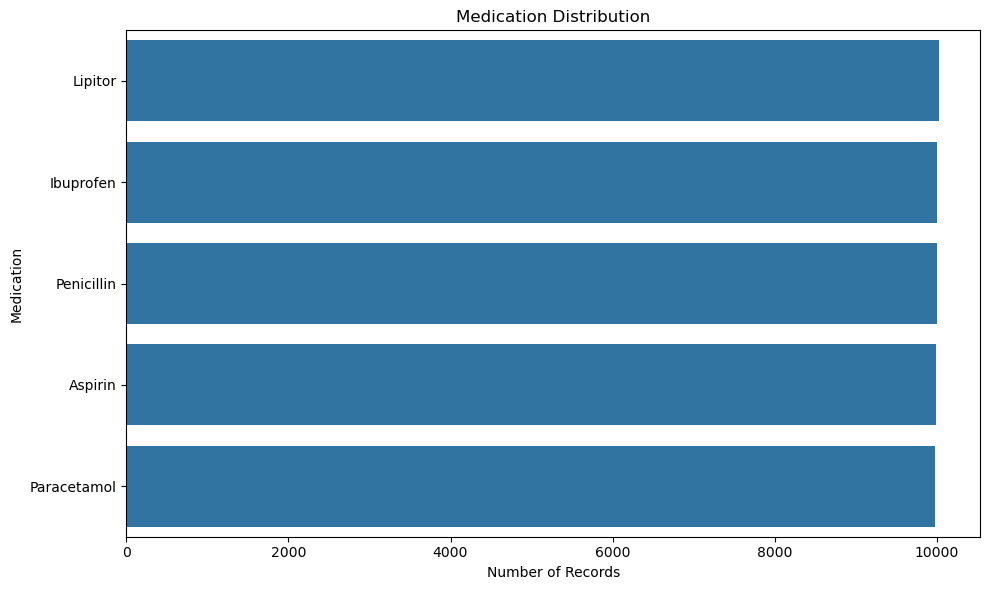

In [ ]:
medication_counts = df["Medication"].value_counts()

print(medication_counts)

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Medication",
    order=medication_counts.index
)

plt.title("Medication Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Medication")
plt.tight_layout()
plt.show()

Admission Year
2019     6634
2020    10155
2021     9883
2022     9935
2023     9929
2024     3460
Name: count, dtype: int64


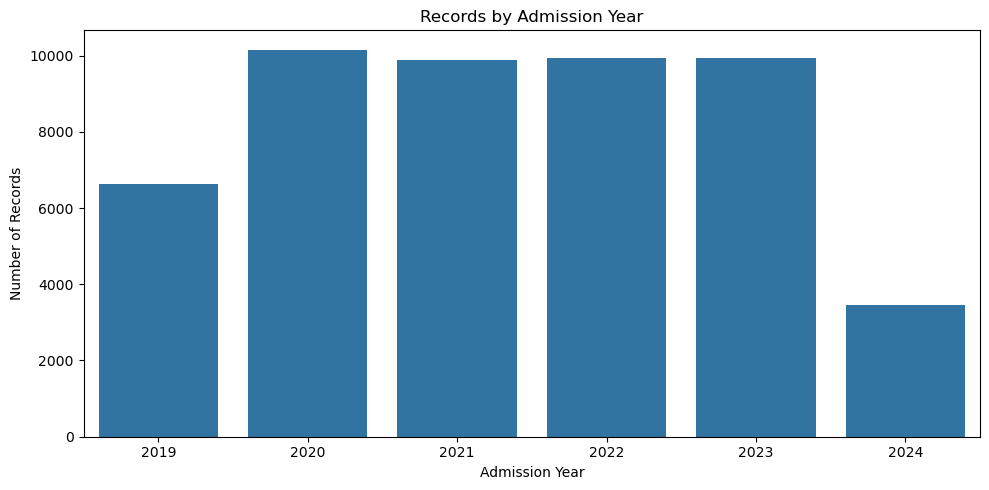

In [ ]:
df["Admission Year"] = df["Date of Admission"].dt.year

year_counts = df["Admission Year"].value_counts().sort_index()

print(year_counts)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Admission Year",
    order=sorted(df["Admission Year"].unique())
)

plt.title("Records by Admission Year")
plt.xlabel("Admission Year")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [ ]:
df["Admission Month"] = df["Date of Admission"].dt.month

monthly_admissions = (
    df["Admission Month"]
    .value_counts()
    .sort_index()
)

monthly_admissions

Admission Month
1     4286
2     3770
3     4324
4     4074
5     4182
6     4216
7     4245
8     4296
9     4167
10    4165
11    4025
12    4246
Name: count, dtype: int64

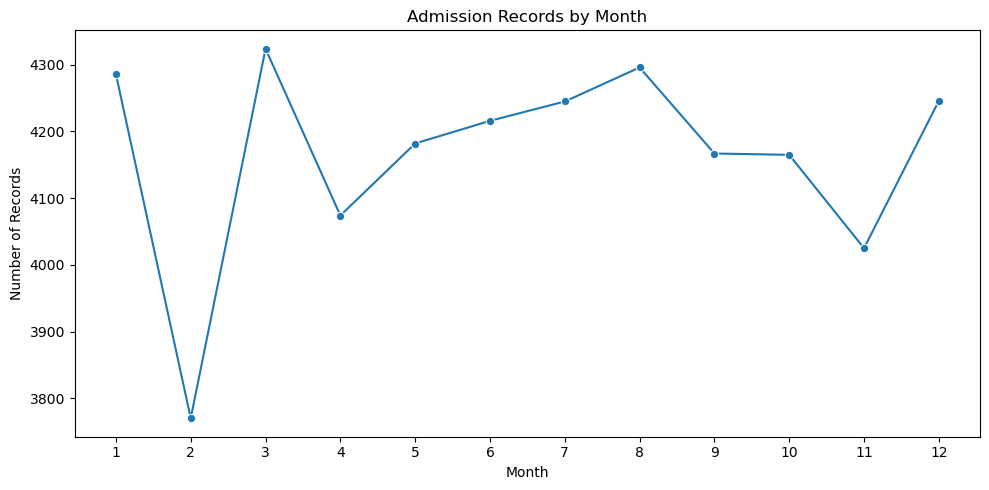

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_admissions.index,
    y=monthly_admissions.values,
    marker="o"
)

plt.title("Admission Records by Month")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [ ]:
high_cost_threshold = df["Billing Amount"].quantile(0.90)

print("High-Cost Threshold:", round(high_cost_threshold, 2))

High-Cost Threshold: 45200.98


In [ ]:
df["High Cost"] = np.where(
    df["Billing Amount"] >= high_cost_threshold,
    "High Cost",
    "Regular"
)

high_cost_summary = df["High Cost"].value_counts()

print(high_cost_summary)

print("\nPercentage:")
print(
    (df["High Cost"].value_counts(normalize=True) * 100).round(2)
)

High Cost
Regular      44996
High Cost     5000
Name: count, dtype: int64

Percentage:
High Cost
Regular      90.0
High Cost    10.0
Name: proportion, dtype: float64


In [ ]:
high_cost_by_condition = (
    df[df["High Cost"] == "High Cost"]
    ["Medical Condition"]
    .value_counts()
)

high_cost_by_condition

Medical Condition
Hypertension    877
Arthritis       864
Asthma          840
Diabetes        837
Cancer          792
Obesity         790
Name: count, dtype: int64

In [ ]:
condition_summary = (
    df.groupby("Medical Condition")
    .agg(
        Records=("Medical Condition", "size"),
        Average_Billing=("Billing Amount", "mean"),
        Median_Billing=("Billing Amount", "median"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Stay=("Stay_Duration_Days", "mean"),
        Median_Stay=("Stay_Duration_Days", "median"),
        Average_Age=("Age", "mean")
    )
    .sort_values("Records", ascending=False)
)

condition_summary

,Records,Average_Billing,Median_Billing,Total_Billing,Average_Stay,Median_Stay,Average_Age
Medical Condition,,,,,,,
Arthritis,8438,25487.482119,25555.365,2.150634e+08,15.555582,16.0,51.593624
Diabetes,8383,25653.842634,25619.170,2.150562e+08,15.409400,15.0,51.526303
Hypertension,8318,25493.762037,25264.310,2.120571e+08,15.446862,15.0,51.670955
Cancer,8293,25237.913104,25060.650,2.092980e+08,15.473170,15.0,51.513445
Obesity,8292,25786.131393,26134.725,2.138186e+08,15.456223,15.0,51.364689
Asthma,8272,25683.606587,25678.670,2.124548e+08,15.665135,16.0,51.716030


In [ ]:
admission_summary = (
    df.groupby("Admission Type")
    .agg(
        Records=("Admission Type", "size"),
        Average_Billing=("Billing Amount", "mean"),
        Median_Billing=("Billing Amount", "median"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Stay=("Stay_Duration_Days", "mean"),
        Median_Stay=("Stay_Duration_Days", "median")
    )
    .sort_values("Records", ascending=False)
)

admission_summary

,Records,Average_Billing,Median_Billing,Total_Billing,Average_Stay,Median_Stay
Admission Type,,,,,,
Elective,16826,25621.458785,25653.88,4.311067e+08,15.517057,15.0
Urgent,16783,25520.173862,25530.04,4.283051e+08,15.392183,15.0
Emergency,16387,25528.547914,25487.49,4.183363e+08,15.595838,16.0


In [ ]:
insurance_summary = (
    df.groupby("Insurance Provider")
    .agg(
        Records=("Insurance Provider", "size"),
        Average_Billing=("Billing Amount", "mean"),
        Median_Billing=("Billing Amount", "median"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Stay=("Stay_Duration_Days", "mean")
    )
    .sort_values("Records", ascending=False)
)

insurance_summary

,Records,Average_Billing,Median_Billing,Total_Billing,Average_Stay
Insurance Provider,,,,,
Cigna,10090,25533.770469,25543.825,2.576357e+08,15.499901
Medicare,10057,25625.901882,25616.660,2.577197e+08,15.606742
Blue Cross,10001,25652.320601,25644.980,2.565489e+08,15.512649
UnitedHealthcare,10001,25412.268240,25208.460,2.541481e+08,15.457554
Aetna,9847,25560.644445,25747.810,2.516957e+08,15.426221


In [ ]:
hospital_summary = (
    df.groupby("Hospital")
    .agg(
        Records=("Hospital", "size"),
        Average_Billing=("Billing Amount", "mean"),
        Median_Billing=("Billing Amount", "median"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Stay=("Stay_Duration_Days", "mean"),
        Median_Stay=("Stay_Duration_Days", "median")
    )
    .sort_values("Records", ascending=False)
)

hospital_summary.head(20)

,Records,Average_Billing,Median_Billing,Total_Billing,Average_Stay,Median_Stay
Hospital,,,,,,
LLC Smith,40,23714.027500,19516.355,948561.10,15.600000,17.0
Smith Ltd,35,25648.424571,23435.930,897694.86,15.257143,15.0
Johnson PLC,35,29726.617143,30447.000,1040431.60,16.228571,17.0
Ltd Smith,35,26147.622000,25306.050,915166.77,16.971429,17.0
Smith PLC,33,27313.917879,28675.530,901359.29,16.818182,21.0
Smith Group,32,23134.404687,23332.455,740300.95,16.718750,17.0
Group Smith,30,28248.358667,25115.165,847450.76,15.900000,13.5
Johnson Inc,29,27898.409310,31095.430,809053.87,14.344828,13.0
Smith Inc,29,22583.677931,21676.750,654926.66,15.448276,13.0


In [ ]:
numeric_columns = [
    "Age",
    "Billing Amount",
    "Room Number",
    "Stay_Duration_Days",
    "Daily_Billing_Amount"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix


,Age,Billing Amount,Room Number,Stay_Duration_Days,Daily_Billing_Amount
Age,1.000000,-0.001027,-0.000786,0.007924,-0.007451
Billing Amount,-0.001027,1.000000,-0.003921,-0.004538,0.323942
Room Number,-0.000786,-0.003921,1.000000,-0.004634,0.004261
Stay_Duration_Days,0.007924,-0.004538,-0.004634,1.000000,-0.538146
Daily_Billing_Amount,-0.007451,0.323942,0.004261,-0.538146,1.000000


In [ ]:
print("Top Medical Conditions:")
print(df["Medical Condition"].value_counts().head())

print("\nHighest Average Billing by Condition:")
print(
    df.groupby("Medical Condition")["Billing Amount"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

print("\nHighest Average Length of Stay by Condition:")
print(
    df.groupby("Medical Condition")["Stay_Duration_Days"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

print("\nHighest Average Billing by Admission Type:")
print(
    df.groupby("Admission Type")["Billing Amount"]
    .mean()
    .sort_values(ascending=False)
)

print("\nHighest Average Billing by Insurance Provider:")
print(
    df.groupby("Insurance Provider")["Billing Amount"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

Top Medical Conditions:
Medical Condition
Arthritis       8438
Diabetes        8383
Hypertension    8318
Cancer          8293
Obesity         8292
Name: count, dtype: int64

Highest Average Billing by Condition:
Medical Condition
Obesity         25786.131393
Asthma          25683.606587
Diabetes        25653.842634
Hypertension    25493.762037
Arthritis       25487.482119
Name: Billing Amount, dtype: float64

Highest Average Length of Stay by Condition:
Medical Condition
Asthma          15.665135
Arthritis       15.555582
Cancer          15.473170
Obesity         15.456223
Hypertension    15.446862
Name: Stay_Duration_Days, dtype: float64

Highest Average Billing by Admission Type:
Admission Type
Elective     25621.458785
Emergency    25528.547914
Urgent       25520.173862
Name: Billing Amount, dtype: float64

Highest Average Billing by Insurance Provider:
Insurance Provider
Blue Cross          25652.320601
Medicare            25625.901882
Aetna               25560.644445
Cigna        